In [ ]:
## To do
[] feature 별 class 구분 시각화 
[] pair plot

# *Libraries*

In [32]:
# 기본 라이브러리
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 머신러닝 관련 라이브러리
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

# FutureWarning 무시
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import matplotlib.pyplot as plt
from matplotlib import rc
import platform

# 1. 운영체제(OS)에 따른 폰트 설정
system_name = platform.system()

if system_name == 'Windows':
    # 윈도우의 경우 '맑은 고딕' 설정
    rc('font', family='Malgun Gothic')
elif system_name == 'Darwin':
    # Mac의 경우 '애플고딕' 설정
    rc('font', family='AppleGothic')
elif system_name == 'Linux':
    # 리눅스(Colab 등)의 경우 기본 설치된 한글 폰트 확인 필요 (보통 NanumGothic)
    # 아래는 Ubuntu 계열에서 'NanumGothic'이 설치되어 있다고 가정
    rc('font', family='NanumGothic')
else:
    print("Unknown System. Please set font manually.")

# 2. 마이너스 기호(-)가 깨지는 현상 방지
# 한글 폰트로 변경 시, 기본적으로 사용되는 마이너스 기호가 깨질 수 있어 이를 False로 설정
plt.rcParams['axes.unicode_minus'] = False

# *Load Data*

In [33]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("lavanyashukla01/particle-identification")

print("Path to dataset files:", path)

Path to dataset files: /Users/Jongseok/.cache/kagglehub/datasets/lavanyashukla01/particle-identification/versions/1


In [34]:
import pandas as pd
import os

# 데이터 저장 경로 (사용자 환경에 따라 다를 수 있음)
base_path = "/Users/Jongseok/.cache/kagglehub/datasets/lavanyashukla01/particle-identification/versions/1"


# 1. 폴더 안에 있는 파일 목록 확인
if os.path.exists(base_path):
    file_list = os.listdir(base_path)
    print("파일 목록:", file_list)
    
    # 2. CSV 파일 찾기 (보통 training.csv 또는 data.csv)
    csv_files = [f for f in file_list if f.endswith('.csv')]
    
    if len(csv_files) > 0:
        full_path1 = os.path.join(base_path, csv_files[0])
        full_path2 = os.path.join(base_path, csv_files[1])

        train_df = pd.read_csv(full_path1)
        test_df = pd.read_csv(full_path2)
        
        print(f"Load complete: \n Train : {train_df.shape}, Test : {test_df.shape}")
            
    else:
        print("❌ 폴더는 찾았지만, .csv 파일이 보이지 않습니다. 압축(.zip)이 덜 풀렸는지 확인이 필요합니다.")
else:
    print(f"❌ 경로를 찾을 수 없습니다: {base_path}")

파일 목록: ['training.csv', 'test.csv']
Load complete: 
 Train : (1200000, 50), Test : (1200000, 50)


# *Data Overview*

In [35]:
df_train = train_df.copy() ; df_test = test_df.copy()

In [36]:
# 데이터 구조 확인
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200000 entries, 0 to 1199999
Data columns (total 50 columns):
 #   Column                           Non-Null Count    Dtype  
---  ------                           --------------    -----  
 0   TrackP                           1200000 non-null  float64
 1   TrackNDoFSubdetector2            1200000 non-null  float64
 2   BremDLLbeElectron                1200000 non-null  float64
 3   MuonLooseFlag                    1200000 non-null  float64
 4   FlagSpd                          1200000 non-null  float64
 5   SpdE                             1200000 non-null  float64
 6   EcalDLLbeElectron                1200000 non-null  float64
 7   DLLmuon                          1200000 non-null  float64
 8   RICHpFlagElectron                1200000 non-null  float64
 9   EcalDLLbeMuon                    1200000 non-null  float64
 10  TrackQualitySubdetector2         1200000 non-null  float64
 11  FlagPrs                          1200000 non-null 

In [37]:
# 데이터 확인
df_train.head()
# Head()를 통해 데이터 확인 후, -999와 같은 이상치 확인 => 이는 보통 NaN값 대신 채워지는 값으로, 이상치 처리 필요
# 이를 그대로 두가 정규화 할 경우, 분포가 심각하게 망가짐

,TrackP,TrackNDoFSubdetector2,BremDLLbeElectron,MuonLooseFlag,FlagSpd,SpdE,EcalDLLbeElectron,DLLmuon,RICHpFlagElectron,EcalDLLbeMuon,...,TrackNDoF,RICHpFlagMuon,RICH_DLLbeKaon,RICH_DLLbeElectron,HcalE,MuonFlag,FlagMuon,PrsE,RICH_DLLbeMuon,RICH_DLLbeProton
0,74791.156263,15.0,0.232275,1.0,1.0,3.2,-2.505719,6.604153,1.0,1.929960,...,28.0,1.0,-7.213300,-0.280200,5586.589846,1.0,1.0,10.422315,-2.081143e-07,-24.824400
1,2738.489989,15.0,-0.357748,0.0,1.0,3.2,1.864351,0.263651,1.0,-2.061959,...,32.0,1.0,-0.324317,1.707283,-0.000007,0.0,1.0,43.334935,2.771583e+00,-0.648017
2,2161.409908,17.0,-999.000000,0.0,0.0,-999.0,-999.000000,-999.000000,0.0,-999.000000,...,27.0,0.0,-999.000000,-999.000000,-999.000000,0.0,0.0,-999.000000,-9.990000e+02,-999.000000
3,15277.730490,20.0,-0.638984,0.0,1.0,3.2,-2.533918,-8.724949,1.0,-3.253981,...,36.0,1.0,-35.202221,-14.742319,4482.803707,0.0,1.0,2.194175,-3.070819e+00,-29.291519
4,7563.700195,19.0,-0.638962,0.0,1.0,3.2,-2.087146,-7.060422,1.0,-0.995816,...,33.0,1.0,25.084287,-10.272412,5107.554680,0.0,1.0,0.000015,-5.373712e+00,23.653087


In [38]:
# 기초통계량 확인
df_train.describe()

,TrackP,TrackNDoFSubdetector2,BremDLLbeElectron,MuonLooseFlag,FlagSpd,SpdE,EcalDLLbeElectron,DLLmuon,RICHpFlagElectron,EcalDLLbeMuon,...,TrackNDoF,RICHpFlagMuon,RICH_DLLbeKaon,RICH_DLLbeElectron,HcalE,MuonFlag,FlagMuon,PrsE,RICH_DLLbeMuon,RICH_DLLbeProton
count,1.200000e+06,1.200000e+06,1.200000e+06,1.200000e+06,1.200000e+06,1.200000e+06,1.200000e+06,1.200000e+06,1.200000e+06,1.200000e+06,...,1.200000e+06,1.200000e+06,1.200000e+06,1.200000e+06,1.200000e+06,1.200000e+06,1.200000e+06,1.200000e+06,1.200000e+06,1.200000e+06
mean,1.614162e+04,1.475170e+01,-2.077315e+02,1.908400e-01,8.531908e-01,-1.443849e+02,-1.828275e+02,-1.266902e+01,9.514050e-01,-1.830022e+02,...,2.942221e+01,9.187425e-01,-5.183805e+01,-5.103860e+01,2.900030e+03,1.662333e-01,8.209933e-01,-1.338948e+02,-4.919965e+01,-5.223401e+01
std,2.790366e+04,4.038073e+00,4.054632e+02,3.929634e-01,3.539157e-01,3.545035e+02,3.854803e+02,1.049158e+02,2.150199e-01,3.853958e+02,...,6.029159e+00,2.732303e-01,2.153209e+02,2.150846e+02,7.686446e+03,3.722901e-01,3.833581e-01,3.628977e+02,2.147605e+02,2.152330e+02
min,1.115380e+03,1.000000e+00,-9.990000e+02,0.000000e+00,0.000000e+00,-9.990000e+02,-9.990000e+02,-9.990000e+02,0.000000e+00,-9.990000e+02,...,7.000000e+00,0.000000e+00,-9.990000e+02,-9.990000e+02,-9.990000e+02,0.000000e+00,0.000000e+00,-9.990000e+02,-9.990000e+02,-9.990000e+02
25%,4.137650e+03,1.300000e+01,-6.389485e-01,0.000000e+00,1.000000e+00,0.000000e+00,-3.000639e+00,-5.711142e+00,1.000000e+00,-3.367626e+00,...,2.600000e+01,1.000000e+00,-1.469941e+01,-1.310509e+01,-1.438680e-05,0.000000e+00,1.000000e+00,9.222748e-06,-4.503331e+00,-1.619484e+01
50%,8.069835e+03,1.600000e+01,-5.329026e-01,0.000000e+00,1.000000e+00,3.200000e+00,-2.321410e+00,-1.988139e+00,1.000000e+00,-1.956064e+00,...,3.000000e+01,1.000000e+00,-1.207258e-06,-2.356098e+00,5.780127e+02,0.000000e+00,1.000000e+00,2.468449e+00,-4.697510e-01,-2.928758e-06
75%,1.750157e+04,1.800000e+01,-5.933819e-02,0.000000e+00,1.000000e+00,3.200000e+00,5.918621e-01,1.669210e+00,1.000000e+00,4.339380e-01,...,3.400000e+01,1.000000e+00,8.465107e+00,1.674137e+00,3.046122e+03,0.000000e+00,1.000000e+00,8.502449e+00,1.300086e+00,8.922095e+00
max,4.750951e+06,3.000000e+01,4.791513e+00,1.000000e+00,1.000000e+00,3.200000e+00,4.341298e+00,1.471079e+01,1.000000e+00,2.153017e+00,...,5.200000e+01,1.000000e+00,1.588015e+02,1.861542e+02,8.682200e+05,1.000000e+00,1.000000e+00,2.805800e+02,1.428335e+02,1.462984e+02


In [39]:
# 컬럼명 확인
print(df_train.columns.tolist())

['TrackP', 'TrackNDoFSubdetector2', 'BremDLLbeElectron', 'MuonLooseFlag', 'FlagSpd', 'SpdE', 'EcalDLLbeElectron', 'DLLmuon', 'RICHpFlagElectron', 'EcalDLLbeMuon', 'TrackQualitySubdetector2', 'FlagPrs', 'DLLelectron', 'DLLkaon', 'EcalE', 'TrackQualityPerNDoF', 'DLLproton', 'PrsDLLbeElectron', 'FlagRICH1', 'MuonLLbeBCK', 'FlagHcal', 'EcalShowerLongitudinalParameter', 'Calo2dFitQuality', 'TrackPt', 'TrackDistanceToZ', 'RICHpFlagPion', 'HcalDLLbeElectron', 'Calo3dFitQuality', 'FlagEcal', 'MuonLLbeMuon', 'TrackNDoFSubdetector1', 'RICHpFlagProton', 'RICHpFlagKaon', 'GhostProbability', 'TrackQualitySubdetector1', 'Label', 'RICH_DLLbeBCK', 'FlagRICH2', 'FlagBrem', 'HcalDLLbeMuon', 'TrackNDoF', 'RICHpFlagMuon', 'RICH_DLLbeKaon', 'RICH_DLLbeElectron', 'HcalE', 'MuonFlag', 'FlagMuon', 'PrsE', 'RICH_DLLbeMuon', 'RICH_DLLbeProton']


In [40]:
# 결측치 확인
df_train.isnull().sum()

TrackP                             0
TrackNDoFSubdetector2              0
BremDLLbeElectron                  0
MuonLooseFlag                      0
FlagSpd                            0
SpdE                               0
EcalDLLbeElectron                  0
DLLmuon                            0
RICHpFlagElectron                  0
EcalDLLbeMuon                      0
TrackQualitySubdetector2           0
FlagPrs                            0
DLLelectron                        0
DLLkaon                            0
EcalE                              0
TrackQualityPerNDoF                0
DLLproton                          0
PrsDLLbeElectron                   0
FlagRICH1                          0
MuonLLbeBCK                        0
FlagHcal                           0
EcalShowerLongitudinalParameter    0
Calo2dFitQuality                   0
TrackPt                            0
TrackDistanceToZ                   0
RICHpFlagPion                      0
HcalDLLbeElectron                  0
C

In [41]:
# 중복 데이터 확인
df_train.duplicated().sum()

np.int64(0)

In [42]:
print(df_train['Label'].unique())

['Muon' 'Ghost' 'Pion' 'Proton' 'Kaon' 'Electron']


### 결측치 처리

- 우선 결측치는 -999로 표기되어 있으므로, 이를 NaN으로 변환하여 결측치 처리를 진행
- 결측치는 여러 방법으로 처리할 수 있지만, 여기서는 물리적 특성상 결측치가 있는 행을 제거하는 방식을 사용

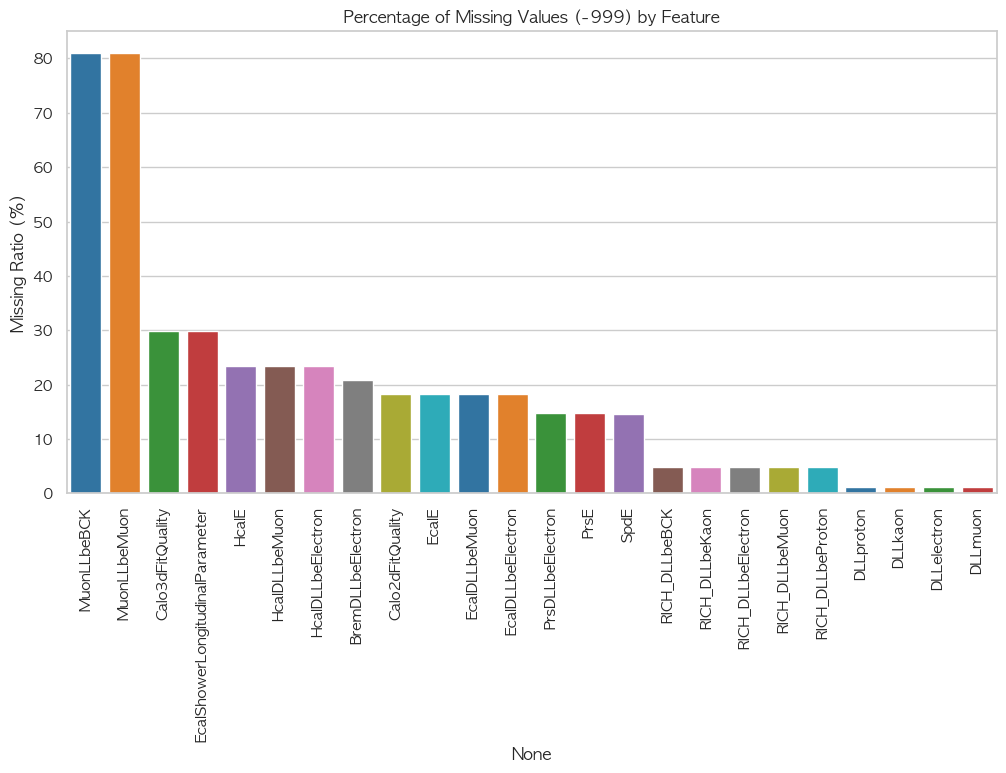

상위 결측 컬럼:
 MuonLLbeBCK                        80.937750
MuonLLbeMuon                       80.937750
Calo3dFitQuality                   29.932750
EcalShowerLongitudinalParameter    29.932750
HcalE                              23.498833
HcalDLLbeMuon                      23.498833
HcalDLLbeElectron                  23.498833
BremDLLbeElectron                  20.796750
Calo2dFitQuality                   18.289417
EcalE                              18.238083
dtype: float64


In [43]:
df_nan = df_train.replace(-999, np.nan)

# 결측치 비율 계산
missing_ratio = df_nan.isnull().sum() / len(df_nan) * 100
missing_ratio = missing_ratio[missing_ratio > 0].sort_values(ascending=False)

# 컬럼별 결측치 비율 시각화
plt.figure(figsize=(12, 6))
sns.barplot(x=missing_ratio.index, y=missing_ratio.values, palette='tab10')
plt.xticks(rotation=90)
plt.title('Percentage of Missing Values (-999) by Feature')
plt.ylabel('Missing Ratio (%)')
plt.show()

# 상위 결측 컬럼 출력
print("상위 결측 컬럼:\n", missing_ratio.head(10))

In [44]:
# 결측치 제외 데이터프레임
df_clean = df_nan.dropna()
print(f"결측치 제거 후 데이터 크기: {df_clean.shape}")

# 기존 데이터프레임 대비 결측치 제거 후 데이터프레임 크기 비교
print(f"기존 데이터프레임 크기: {df_train.shape}")
print(f"결측치 제거 후 데이터프레임 크기: {df_clean.shape}")

# 비율 계산
print(f"결측치 제거 비율: {(1 - df_clean.shape[0] / df_train.shape[0]) * 100:.2f}%")

결측치 제거 후 데이터 크기: (125426, 50)
기존 데이터프레임 크기: (1200000, 50)
결측치 제거 후 데이터프레임 크기: (125426, 50)
결측치 제거 비율: 89.55%


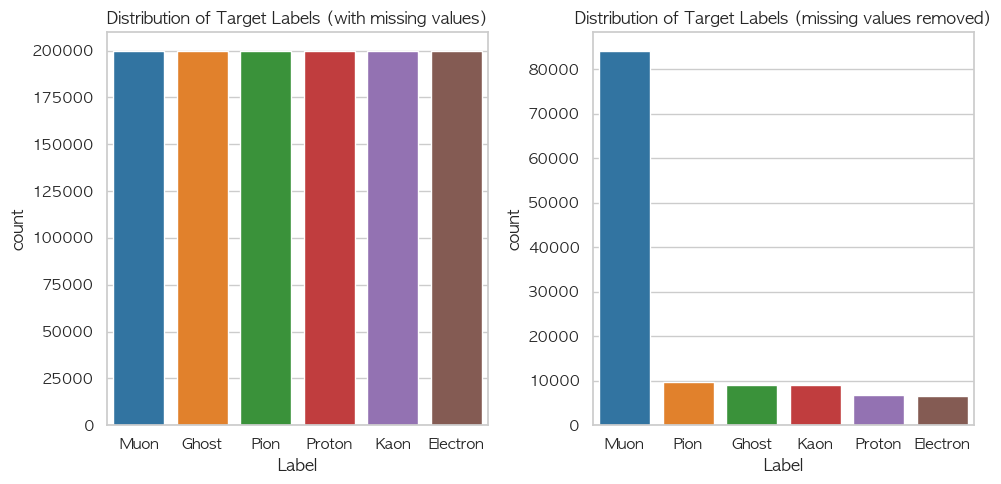

원본 데이터프레임 라벨 분포 비율:
Label
Muon        0.166667
Ghost       0.166667
Pion        0.166667
Proton      0.166667
Kaon        0.166667
Electron    0.166667
Name: proportion, dtype: float64

결측치 제거 후 데이터프레임 라벨 분포 비율:
Label
Muon        0.671456
Pion        0.077201
Ghost       0.072385
Kaon        0.072250
Proton      0.054431
Electron    0.052278
Name: proportion, dtype: float64


In [45]:
# 라벨 분포 시각화 (결측치 포함 vs 결측치 제거 후)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
sns.countplot(x='Label', data=df_train, order=df_train['Label'].value_counts().index, palette='tab10')
plt.title('Distribution of Target Labels (with missing values)')

plt.subplot(1, 2, 2)
sns.countplot(x='Label', data=df_clean, order=df_clean['Label'].value_counts().index, palette='tab10')
plt.title('Distribution of Target Labels (missing values removed)')

plt.tight_layout()
plt.show()


# 수치로 확인
print("원본 데이터프레임 라벨 분포 비율:")
print(df_train['Label'].value_counts(normalize=True))
print("\n결측치 제거 후 데이터프레임 라벨 분포 비율:")
print(df_clean['Label'].value_counts(normalize=True))

# Visualization

<Axes: >

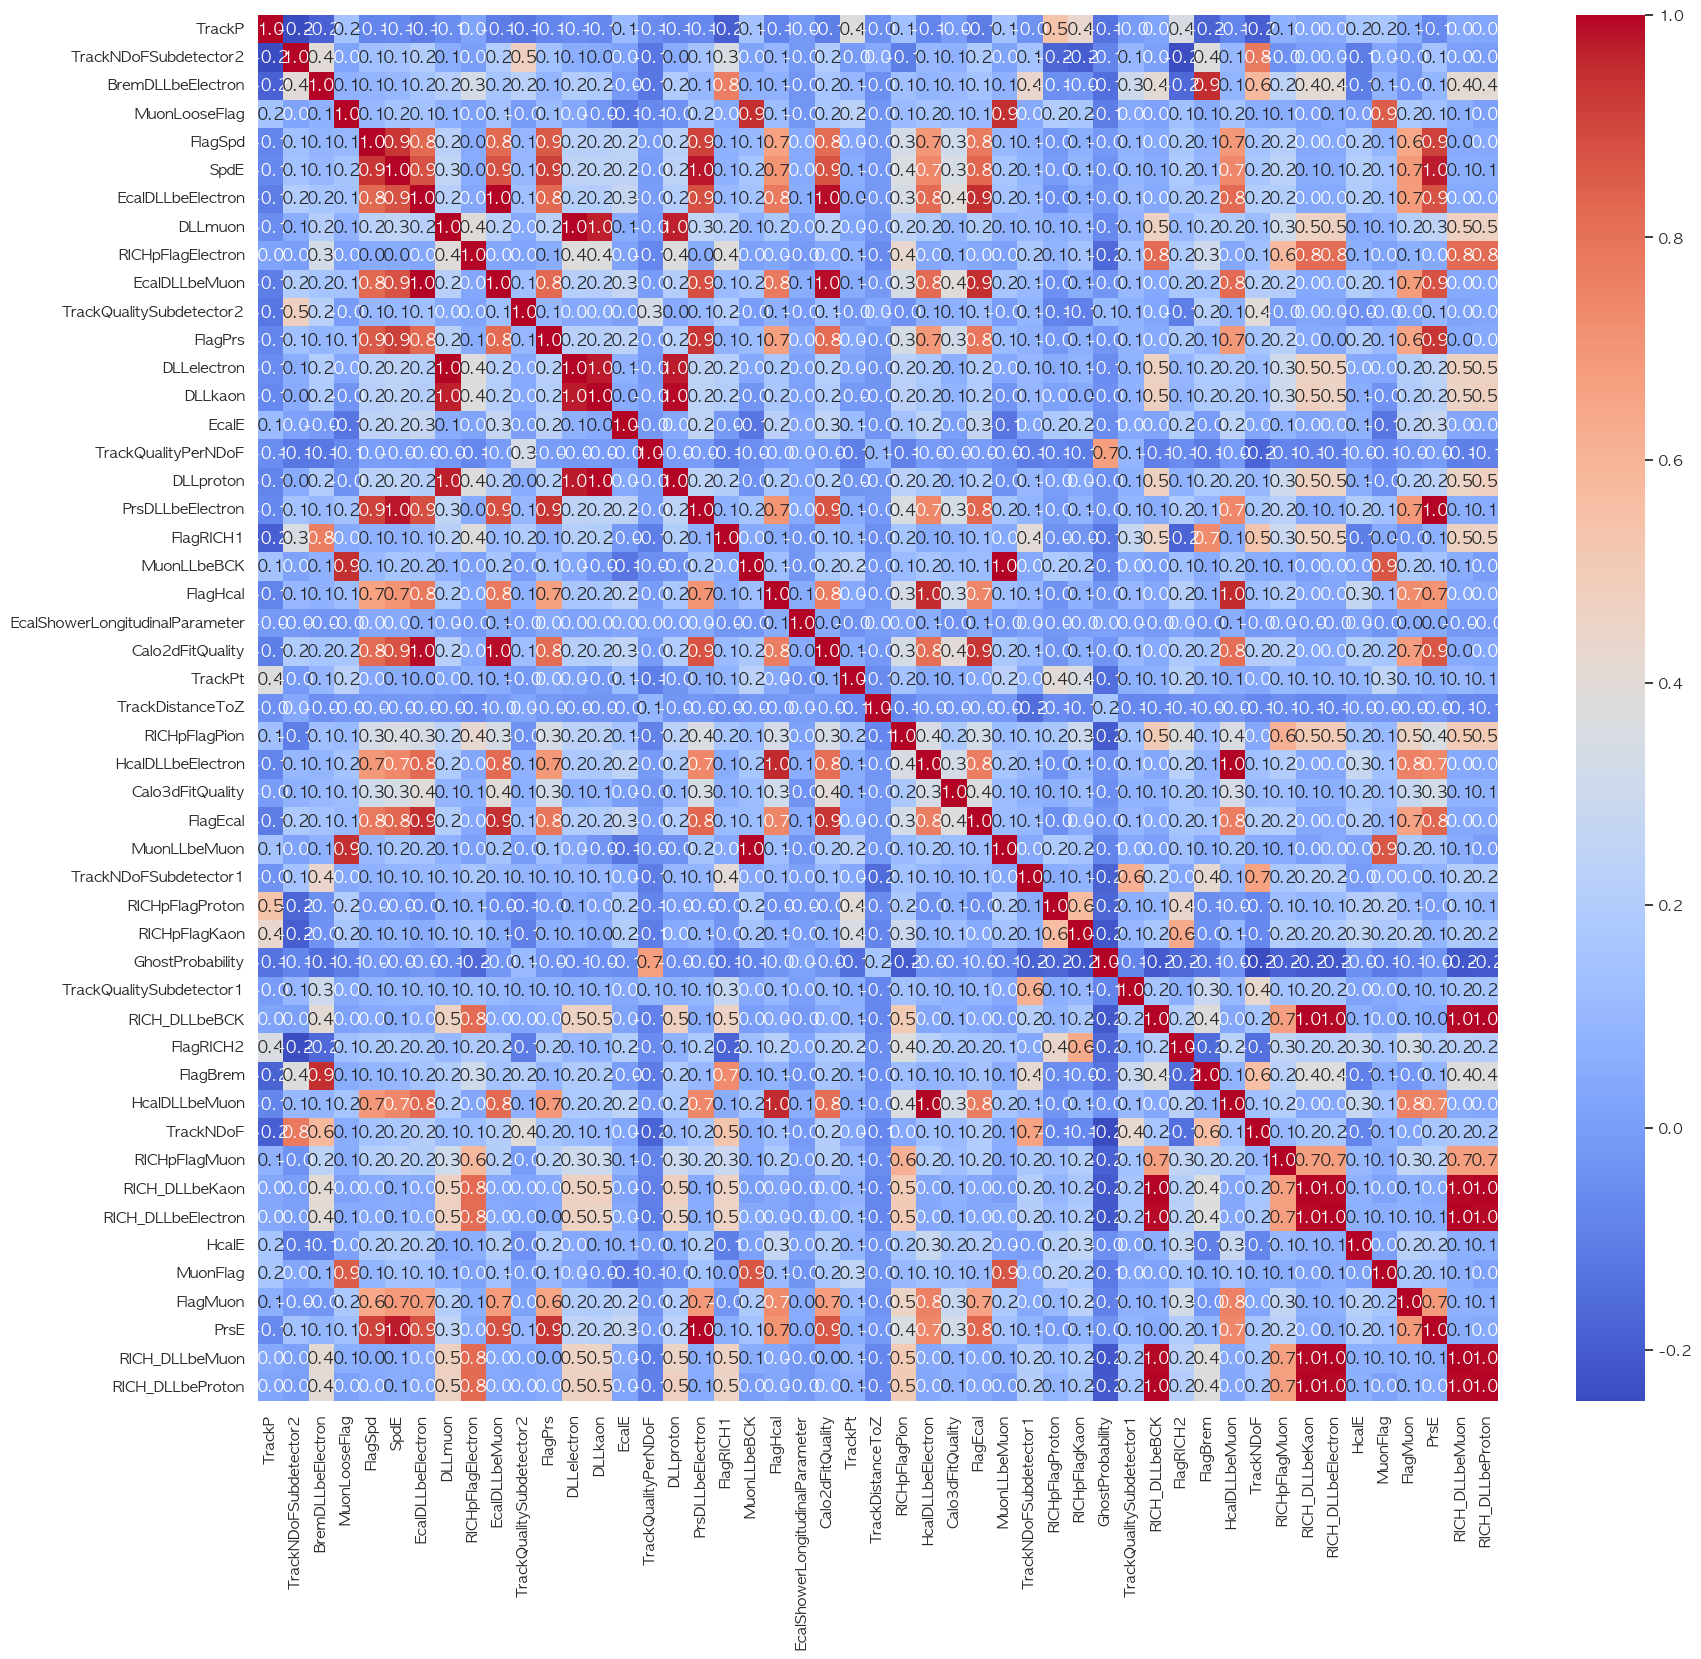

In [46]:
plt.figure(figsize=(20, 18))
numeric_features = df_train.select_dtypes(include=[np.number]).columns.tolist()
sns.heatmap(df_train[numeric_features].corr(), annot=True, fmt=".1f", cmap='coolwarm')

데이터의 물리적 관계를 보여주는 시각화

/opt/anaconda3/envs/SDS_env/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/SDS_env/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


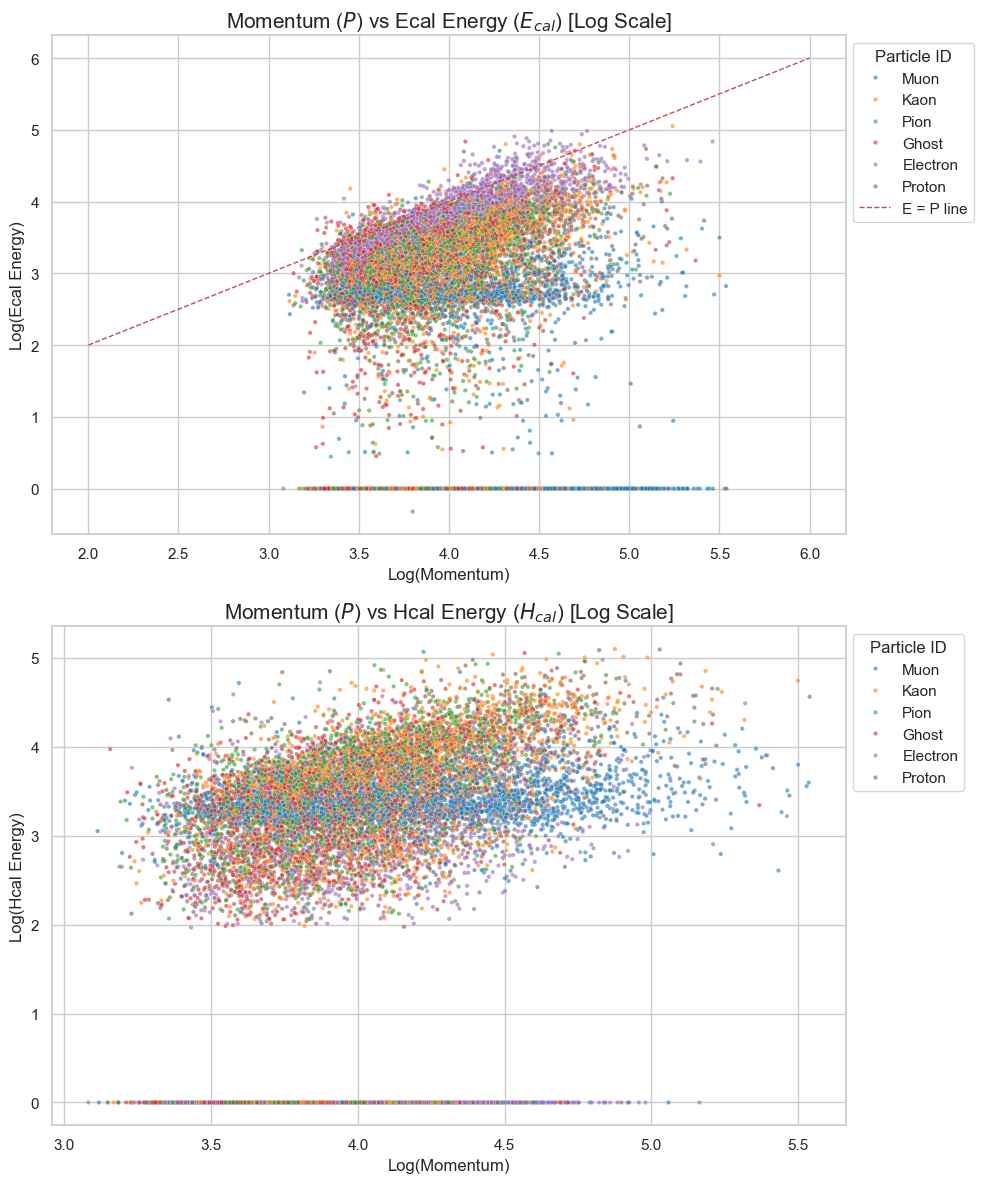

In [47]:
# 1. 데이터 샘플링 (전체 데이터가 너무 크면 시각화가 느려지므로 1만~5만 개만 추출)
df_sample = df_train.sample(n=20000, random_state=42).copy()

# 2. 로그 변환 (Log Transformation)
# 물리 데이터는 0이 포함될 수 있으므로 log(x + 1)을 적용하여 -inf 방지
cols_to_log = ['TrackP', 'EcalE', 'HcalE'] # TrackP: 운동량, EcalE: 전자기 열량계 에너지, HcalE: 강입자 열량계 에너지

for col in cols_to_log:
    df_sample[f'Log_{col}'] = np.log10(df_sample[col] + 1.0)

# 3. 시각화 설정
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 1, figsize=(10, 12))

# Plot 1: 운동량(P) vs 전자기 에너지(Ecal)
# 기대: 전자는 대각선(P ~ E)에 위치, 강입자는 낮게 분포

sns.scatterplot(
    data=df_sample, 
    x='Log_TrackP', 
    y='Log_EcalE', 
    hue='Label', 
    palette='tab10', 
    s=10, 
    alpha=0.6, 
    ax=axes[0]
)
axes[0].set_title('Momentum ($P$) vs Ecal Energy ($E_{cal}$) [Log Scale]', fontsize=15)
axes[0].set_xlabel('Log(Momentum)', fontsize=12)
axes[0].set_ylabel('Log(Ecal Energy)', fontsize=12)
axes[0].plot([2, 6], [2, 6], 'r--', lw=1, label='E = P line') # E=P 기준선 (대략적)
axes[0].legend(title='Particle ID', loc='upper left', bbox_to_anchor=(1, 1))


# Plot 2: 운동량(P) vs 강입자 에너지(Hcal)
# 기대: 강입자(Pion, Proton 등)는 대각선 인근 혹은 높게 분포, 전자/뮤온은 낮게 분포

sns.scatterplot(
    data=df_sample, 
    x='Log_TrackP', 
    y='Log_HcalE', 
    hue='Label', 
    palette='tab10', 
    s=10, 
    alpha=0.6, 
    ax=axes[1]
)

axes[1].set_title('Momentum ($P$) vs Hcal Energy ($H_{cal}$) [Log Scale]', fontsize=15)
axes[1].set_xlabel('Log(Momentum)', fontsize=12)
axes[1].set_ylabel('Log(Hcal Energy)', fontsize=12)
axes[1].legend(title='Particle ID', loc='upper left', bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()

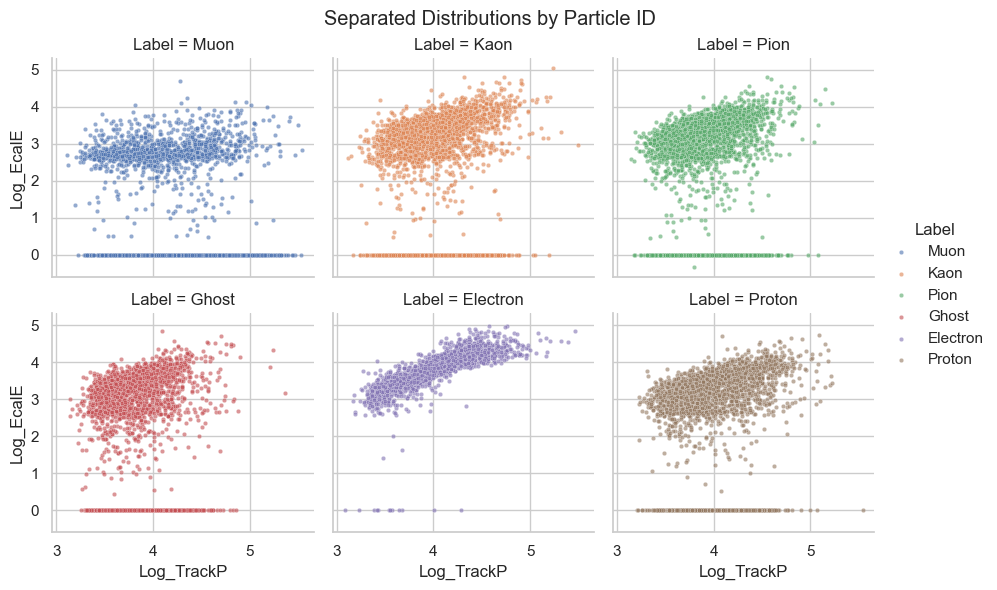

In [48]:
# 각 입자 종류(ID)별로 그래프를 따로 그림
g = sns.FacetGrid(df_sample, col='Label', col_wrap=3, hue='Label', sharey=True, sharex=True)
g.map(sns.scatterplot, "Log_TrackP", "Log_EcalE", s=10, alpha=0.6)
g.add_legend()
plt.subplots_adjust(top=0.9)
g.fig.suptitle('Separated Distributions by Particle ID')
plt.show()

t-SNE 계산 중... 잠시만 기다려주세요.


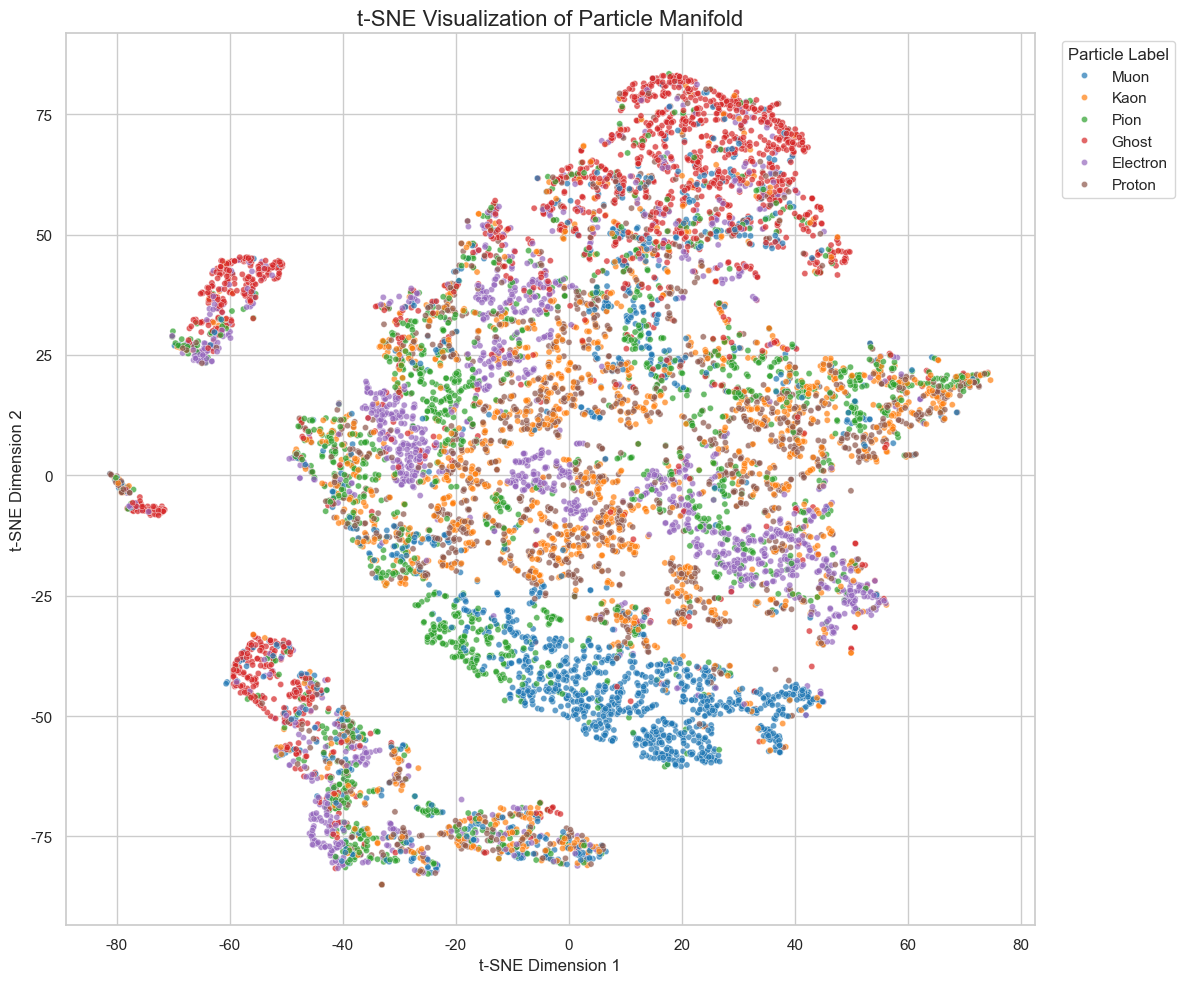

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# 1. 분석에 사용할 주요 Feature 선정 (물리적 의미가 큰 것들 위주)
selected_features = [
    'TrackP', 'TrackPt',            # 운동학적 변수 (Kinematics)
    'EcalE', 'HcalE', 'PrsE',       # 칼로리미터 에너지 (Calorimetry)
    'GhostProbability',             # 노이즈 확률 (중요!)
    'DLLelectron', 'DLLmuon',       # 입자 식별 우도 (PID Likelihoods)
    'DLLkaon', 'DLLproton',
    'RICH_DLLbeElectron',           # RICH 검출기 변수
    'RICH_DLLbeKaon',
    'RICH_DLLbeBCK',
    'RICH_DLLbeProton',
    'TrackQualityPerNDoF'
]
# 데이터 샘플링 (t-SNE는 계산 비용이 높으므로 10,000개만 먼저 시각화)
df_sample = df_train.sample(n=10000, random_state=42).copy()

# 2. 데이터 정규화
X = df_sample[selected_features].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. t-SNE 실행
print("t-SNE 계산 중... 잠시만 기다려주세요.")
tsne = TSNE(n_components=2, perplexity=40, random_state=42, init='pca', learning_rate='auto')
X_embedded = tsne.fit_transform(X_scaled)

# 4. 시각화 데이터프레임 생성
df_tsne = pd.DataFrame(X_embedded, columns=['Dim1', 'Dim2'])
df_tsne['Label'] = df_sample['Label'].values  # 정답 라벨 붙이기

# 5. 그래프 그리기
plt.figure(figsize=(12, 10))
sns.scatterplot(
    data=df_tsne,
    x='Dim1',
    y='Dim2',
    hue='Label',
    palette='tab10',  # 색상 구분이 잘 되는 팔레트
    s=20,
    alpha=0.7,
    legend='full'
)
plt.title('t-SNE Visualization of Particle Manifold', fontsize=16)
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.legend(title='Particle Label', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

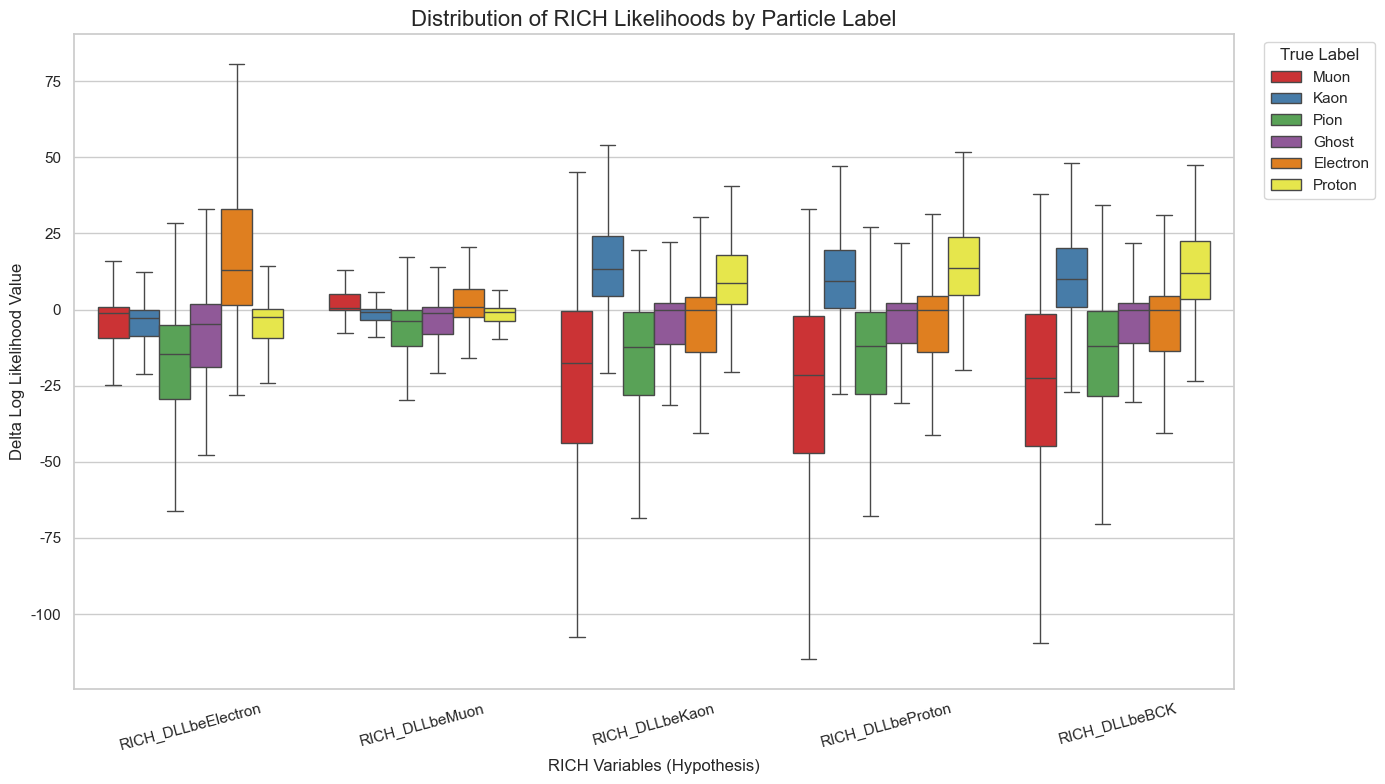

In [50]:
# RICH 관련 컬럼
rich_cols = ['RICH_DLLbeElectron', 'RICH_DLLbeMuon', 'RICH_DLLbeKaon', 'RICH_DLLbeProton', 'RICH_DLLbeBCK']

# 시각화를 위해 데이터 형태 변환 (Wide -> Long)
df_rich = df_sample[['Label'] + rich_cols].melt(
    id_vars=['Label'], 
    value_vars=rich_cols, 
    var_name='RICH_Variable', 
    value_name='Likelihood_Value'
)

# RICH 우도 분포 시각화
plt.figure(figsize=(14, 8))
sns.boxplot(
    data=df_rich, 
    x='RICH_Variable', 
    y='Likelihood_Value', 
    hue='Label', 
    palette='Set1',
    showfliers=False  # 이상치 제외하고 분포 중심 확인
)

plt.title('Distribution of RICH Likelihoods by Particle Label', fontsize=16)
plt.xticks(rotation=15)
plt.xlabel('RICH Variables (Hypothesis)', fontsize=12)
plt.ylabel('Delta Log Likelihood Value', fontsize=12)
plt.legend(title='True Label', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Preprocessing

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import QuantileTransformer, LabelEncoder
import torch
import torch.nn as nn

# Tree 모델용 전처리 함수
def tree_preprocess(df):
    df_tree = df.copy()
    df_tree.replace(-999.0, np.nan, inplace=True)
    return df_tree



# 신경망용 전처리 함수
def preprocess_for_nn(df):
    df_processed = df.copy()
    
    # 1. 결측치 처리 (-999 -> NaN -> Drop)
    df_processed.replace(-999.0, np.nan, inplace=True)
    df_processed = df_processed.dropna()

    df_processed['TRP'] = df_processed['TrackP'] * df_processed['RICH_DLLbeKaon']
    df_processed['KVP'] = df_processed['RICH_DLLbeKaon'] - (df_processed['RICH_DLLbeProton'])

    # 2. Feature 선택
    selected_features = [
        'TrackP', 'TrackPt',            # Kinematics
        'EcalE', 'HcalE', 'PrsE',       # Calorimetry
        'GhostProbability',             # Noise Probability
        'DLLelectron', 'DLLmuon',       # PID Likelihoods
        'DLLkaon', 'DLLproton',
        'RICH_DLLbeElectron',           # RICH Detector
        'RICH_DLLbeKaon',
        'RICH_DLLbeProton',
        'RICHpFlagProton',
        'TRP',
        'KVP'
    ]
    
    X_input = df_processed[selected_features]
    y_input = df_processed['Label']

    # 3. Quantile Transformation (정규분포로 변환)
    numeric_cols = X_input.select_dtypes(include=[np.number]).columns
    
    qt = QuantileTransformer(
        output_distribution='normal', # 정규분포로 변환
        n_quantiles=1000,  # 양자화 수준
        random_state=42
    )

    X_transformed = X_input.copy()
    X_transformed[numeric_cols] = qt.fit_transform(X_input[numeric_cols])

    # 4. Label Encoding
    le = LabelEncoder()
    y_encoded = le.fit_transform(y_input)

    # 5. Tensor 변환 (Float32 for X, Long for y)
    X_tensor = torch.tensor(X_transformed.values, dtype=torch.float32)
    y_tensor = torch.tensor(y_encoded, dtype=torch.long)

    return X_tensor, y_tensor, le

# 적용
df_tree = tree_preprocess(df_train)

# Modeling

## DeepLearning

Preprocessing...
Training data : Train 100340개, Val 25086개
device : mps

Start training...
Epoch [1/10] Train Loss: 0.5823 | Val Loss: 0.4453 | Val Acc: 82.71% | Val F1: 0.8179 | LR: 0.001000
Epoch [2/10] Train Loss: 0.4782 | Val Loss: 0.4397 | Val Acc: 82.99% | Val F1: 0.8150 | LR: 0.001000
Epoch [3/10] Train Loss: 0.4669 | Val Loss: 0.4319 | Val Acc: 83.02% | Val F1: 0.8219 | LR: 0.001000
Epoch [4/10] Train Loss: 0.4589 | Val Loss: 0.4278 | Val Acc: 83.02% | Val F1: 0.8210 | LR: 0.001000
Epoch [5/10] Train Loss: 0.4562 | Val Loss: 0.4285 | Val Acc: 83.01% | Val F1: 0.8235 | LR: 0.001000
Epoch [6/10] Train Loss: 0.4533 | Val Loss: 0.4254 | Val Acc: 83.29% | Val F1: 0.8259 | LR: 0.001000
Epoch [7/10] Train Loss: 0.4507 | Val Loss: 0.4264 | Val Acc: 83.18% | Val F1: 0.8243 | LR: 0.001000
Epoch [8/10] Train Loss: 0.4479 | Val Loss: 0.4237 | Val Acc: 83.52% | Val F1: 0.8242 | LR: 0.001000
Epoch [9/10] Train Loss: 0.4465 | Val Loss: 0.4221 | Val Acc: 83.47% | Val F1: 0.8254 | LR: 0.001000


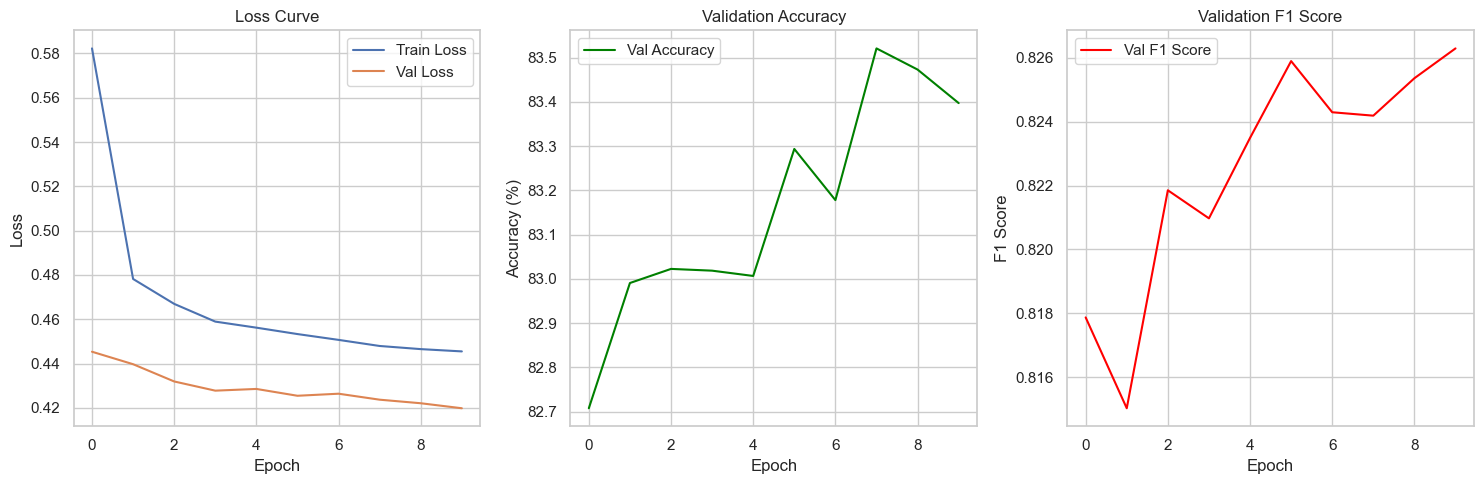

In [52]:
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt

# [1] 전처리 함수 정의



# 0. 데이터 로드 가정 (df_train이 이미 메모리에 있다고 가정)
# df_train = pd.read_csv('your_dataset.csv') # 실제 사용 시 주석 해제

print("Preprocessing...")

# 1. 전처리 실행
X_mlp, y_mlp, label_encoder = preprocess_for_nn(df_train)

# 2. Train/Validation Split
X_train, X_val, y_train, y_val = train_test_split(
    X_mlp, y_mlp, test_size=0.2, random_state=42, stratify=y_mlp
)

# 3. DataLoader 생성
BATCH_SIZE = 256
train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Training data : Train {len(X_train)}개, Val {len(X_val)}개")

# 4. 모델 정의
class DeepParticleClassifier(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(DeepParticleClassifier, self).__init__()
        self.layers = nn.Sequential(
            # Layer 1
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.3),
            
            # Layer 2
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.3),
            
            # Layer 3
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.2),
            
            # Output Layer
            nn.Linear(64, output_dim)
        )
        
    def forward(self, x):
        return self.layers(x)

# 5. 장치 및 모델 초기화
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"device : {device}")

input_dim = X_train.shape[1]
output_dim = len(label_encoder.classes_)
model = DeepParticleClassifier(input_dim, output_dim).to(device)

# 6. Optimizer & Loss
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
criterion = nn.CrossEntropyLoss()

# 7. 학습 루프
EPOCHS = 10
history = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'val_f1': []}

print("\nStart training...")
for epoch in range(EPOCHS):
    # --- Training ---
    model.train()
    running_loss = 0.0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
    avg_train_loss = running_loss / len(train_loader)
    
    # --- Validation ---
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    
    # F1 Score 계산을 위해 모든 예측값과 라벨을 모음
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    avg_val_loss = val_loss / len(val_loader)
    val_acc = 100 * correct / total
    
    # Epoch 단위로 F1 Score 계산
    val_f1 = f1_score(all_labels, all_preds, average='weighted')
    
    # Scheduler Step
    scheduler.step(avg_val_loss)
    current_lr = optimizer.param_groups[0]['lr']
    
    # History 저장
    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)

    print(f"Epoch [{epoch+1}/{EPOCHS}] "
          f"Train Loss: {avg_train_loss:.4f} | "
          f"Val Loss: {avg_val_loss:.4f} | "
          f"Val Acc: {val_acc:.2f}% | "
          f"Val F1: {val_f1:.4f} | "
          f"LR: {current_lr:.6f}")
            
print("Training completed.")

# 8. 결과 시각화
plt.figure(figsize=(15, 5))

# Loss Plot
plt.subplot(1, 3, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Accuracy Plot
plt.subplot(1, 3, 2)
plt.plot(history['val_acc'], label='Val Accuracy', color='green')
plt.title('Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()

# F1 Score Plot
plt.subplot(1, 3, 3)
plt.plot(history['val_f1'], label='Val F1 Score', color='red')
plt.title('Validation F1 Score')
plt.xlabel('Epoch')
plt.ylabel('F1 Score')
plt.legend()

plt.tight_layout()
plt.show()


Classification Report
              precision    recall  f1-score   support

    Electron       0.86      0.92      0.89      1311
       Ghost       0.64      0.65      0.65      1816
        Kaon       0.51      0.40      0.44      1813
        Muon       0.92      0.96      0.94     16844
        Pion       0.69      0.55      0.61      1937
      Proton       0.46      0.42      0.44      1365

    accuracy                           0.83     25086
   macro avg       0.68      0.65      0.66     25086
weighted avg       0.82      0.83      0.83     25086



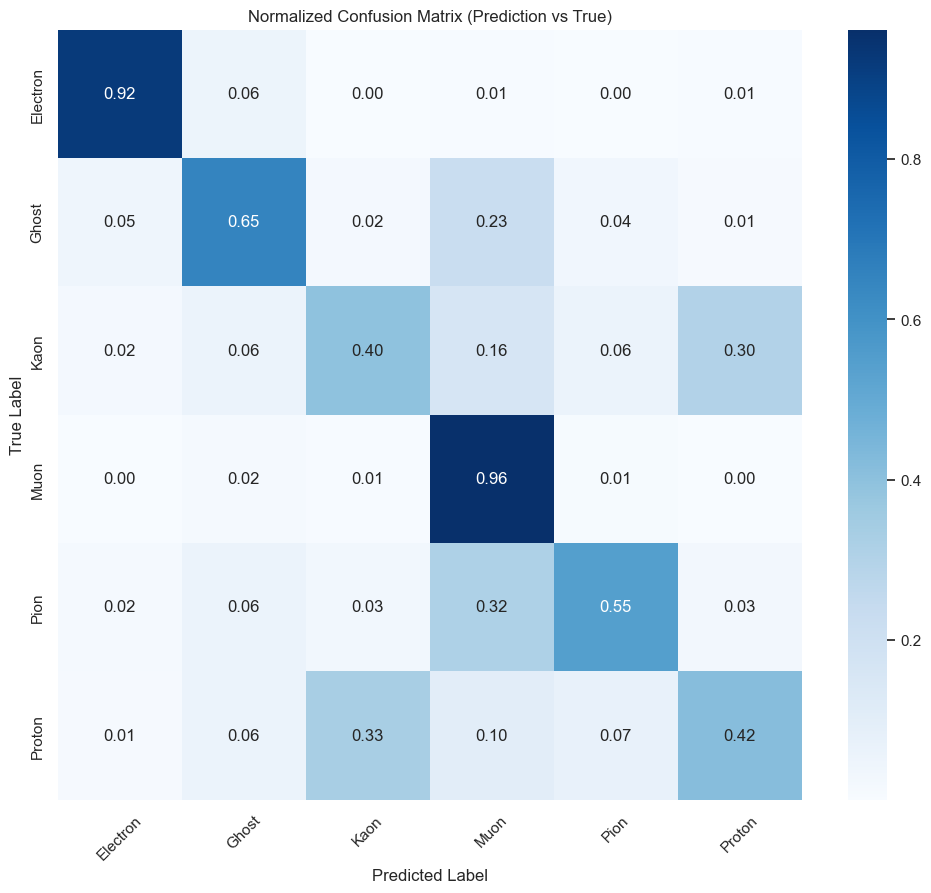

In [55]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_per_class(model, data_loader, label_encoder, device):
    model.eval()
    all_preds = []
    all_labels = []
    
    # 1. 전체 데이터에 대해 예측 수행
    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    # 2. 원래 라벨 이름으로 변환
    target_names = label_encoder.classes_
    
    # 3. Classification Report
    print("\n" + "="*60)
    print("Classification Report")
    print("="*60)
    print(classification_report(all_labels, all_preds, target_names=target_names))

    # 4. Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds, normalize='true') # 'true'로 설정하면 비율(%)로 표시됨
    
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', 
                xticklabels=target_names, yticklabels=target_names)
    plt.title('Normalized Confusion Matrix (Prediction vs True)')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.xticks(rotation=45)
    plt.show()

# 평가 실행
evaluate_per_class(model, val_loader, label_encoder, device)

Model Training Started...
[0]	validation_0-mlogloss:1.71260
[100]	validation_0-mlogloss:0.63861
[200]	validation_0-mlogloss:0.59081
[300]	validation_0-mlogloss:0.57011
[400]	validation_0-mlogloss:0.55887
[499]	validation_0-mlogloss:0.55144

[Evaluation Results]
Validation Accuracy: 0.7756
Validation F1 Score: 0.7739

Classification Report:
              precision    recall  f1-score   support

    Electron       0.89      0.89      0.89     40000
       Ghost       0.76      0.81      0.78     40000
        Kaon       0.66      0.63      0.65     40000
        Muon       0.92      0.92      0.92     40000
        Pion       0.73      0.80      0.76     40000
      Proton       0.68      0.61      0.64     40000

    accuracy                           0.78    240000
   macro avg       0.77      0.78      0.77    240000
weighted avg       0.77      0.78      0.77    240000



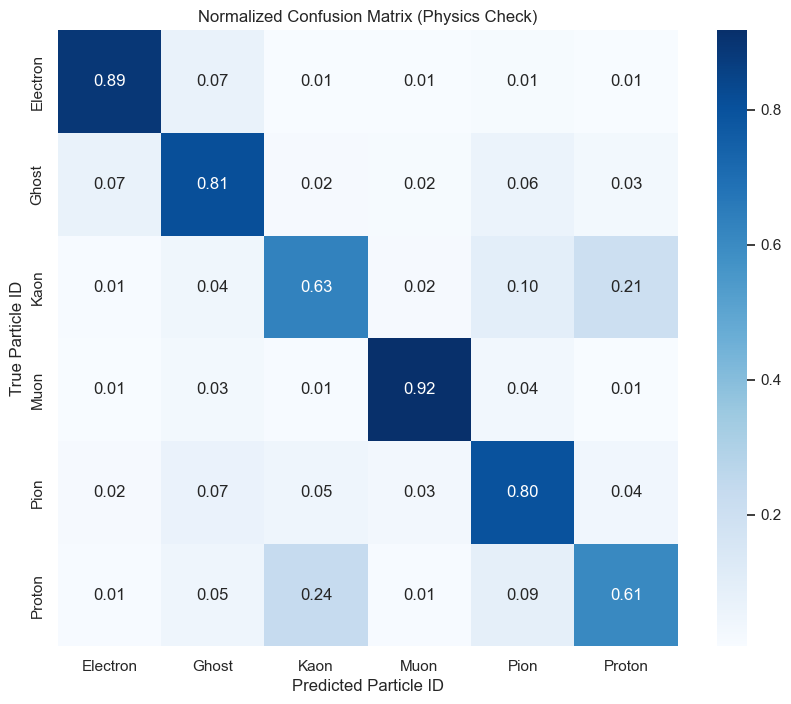

<Figure size 1200x800 with 0 Axes>

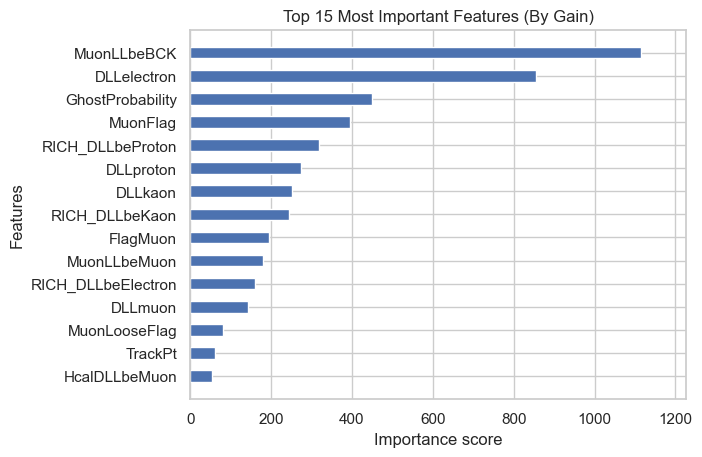

In [ ]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 데이터 준비 및 전처리
df_model = tree_preprocess(df_train)

# Feature와 Label 분리
# User가 제공한 컬럼 리스트에 'Label'이 있었으므로 이를 타겟으로 설정
label_col = 'Label'
X = df_model.drop(columns=[label_col])
y = df_model[label_col]

# Label Encoding 
le = LabelEncoder()
y_encoded = le.fit_transform(y)
class_names = [str(c) for c in le.classes_] # 나중에 시각화용

# Train / Validation Split (8:2)
X_train, X_val, y_train, y_val = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# 2. XGBoost model setup and training
print("Model Training Started...")
xgb_clf = xgb.XGBClassifier(
    n_estimators=500,           # 트리 개수 (충분히 크게 잡고 early_stopping으로 제어)
    learning_rate=0.05,         # 학습률
    max_depth=6,                # 트리의 깊이
    objective='multi:softprob', # 다중 분류 확률값 출력
    num_class=len(class_names), # 클래스 개수
    tree_method='hist',         # 결측치 처리에 최적화된 고속 알고리즘
    random_state=42,
    early_stopping_rounds=20,
    n_jobs=-1                   # 모든 CPU 코어 사용
)

# training
xgb_clf.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=100 # 100번마다 로그 출력
)

# 3. Evaluation
print("\n[Evaluation Results]")
y_pred = xgb_clf.predict(X_val)
acc = accuracy_score(y_val, y_pred)
f1_score = f1_score(y_val, y_pred, average='weighted')
print(f"Validation Accuracy: {acc:.4f}")
print(f"Validation F1 Score: {f1_score:.4f}")
print("\nClassification Report:")
print(classification_report(y_val, y_pred, target_names=class_names))

# --- Visualization 1: Confusion Matrix (Which particles are confused?) ---
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_val, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Normalized Confusion Matrix (Physics Check)')
plt.ylabel('True Particle ID')
plt.xlabel('Predicted Particle ID')
plt.show()

# --- Visualization 2: Feature Importance (What did the model consider important?) ---
plt.figure(figsize=(12, 8))
# Gain: How much the loss function was reduced when the feature was used (Information Gain)
xgb.plot_importance(xgb_clf, importance_type='gain', max_num_features=15, height=0.5, show_values=False)
plt.title('Top 15 Most Important Features (By Gain)')
plt.show()

CatBoost Model Training Started...
0:	learn: 0.6416146	test: 0.6429792	best: 0.6429792 (0)	total: 130ms	remaining: 12.8s
99:	learn: 0.7238042	test: 0.7241875	best: 0.7241875 (99)	total: 11.3s	remaining: 0us

bestTest = 0.7241875
bestIteration = 99


[CatBoost Evaluation]
Validation Accuracy: 0.7242

Classification Report:
              precision    recall  f1-score   support

    Electron       0.84      0.85      0.85     40000
       Ghost       0.70      0.78      0.74     40000
        Kaon       0.63      0.54      0.58     40000
        Muon       0.91      0.85      0.88     40000
        Pion       0.64      0.79      0.70     40000
      Proton       0.62      0.53      0.58     40000

    accuracy                           0.72    240000
   macro avg       0.73      0.72      0.72    240000
weighted avg       0.73      0.72      0.72    240000


[Evaluation Results]

Classification Report:
              precision    recall  f1-score   support

    Electron       0.84      0.8

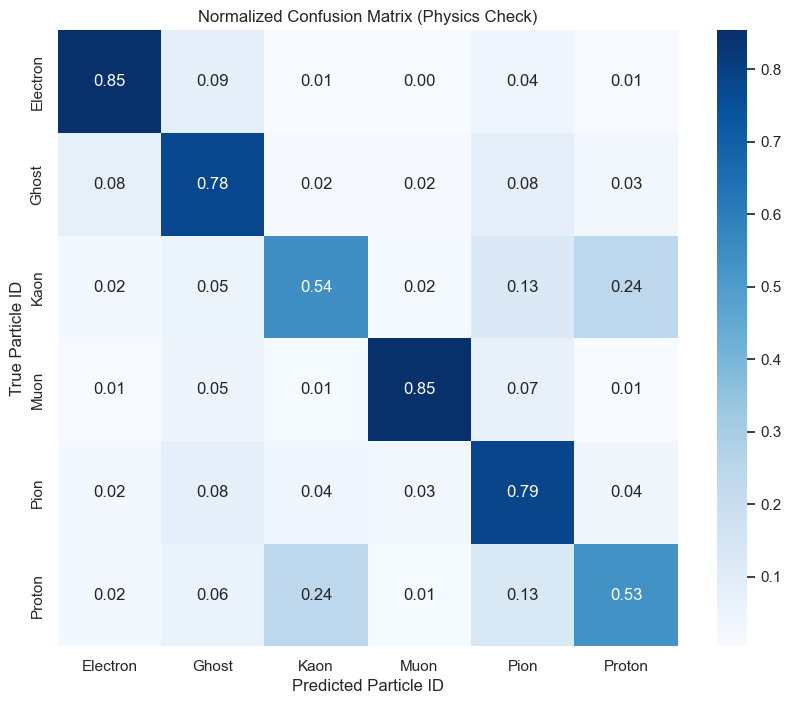

In [60]:
from catboost import CatBoostClassifier, Pool
from sklearn.metrics import accuracy_score

# 1. CatBoost model setup
print("CatBoost Model Training Started...")
cb_clf = CatBoostClassifier(
    iterations=100,            # 트리 개수
    learning_rate=0.05,
    depth=5,
    loss_function='MultiClass', # 다중 분류
    eval_metric='Accuracy',
    random_seed=42,
    verbose=100,                # 100번마다 출력
    early_stopping_rounds=50,   # 조기 종료
    nan_mode='Min'              # 결측치(-999/NaN)를 최솟값으로 처리
)

# 2. Training
train_pool = Pool(X_train, y_train)
val_pool = Pool(X_val, y_val)

cb_clf.fit(
    train_pool,
    eval_set=val_pool,
    plot=False
)

# 3. 평가
print("\n[CatBoost Evaluation]")
y_pred_cb = cb_clf.predict(X_val)
acc_cb = accuracy_score(y_val, y_pred_cb)
print(f"Validation Accuracy: {acc_cb:.4f}")

# classification report
print("\nClassification Report:")
print(classification_report(y_val, y_pred_cb, target_names=class_names))

# 3. 평가 및 검증
print("\n[Evaluation Results]")
y_pred = cb_clf.predict(X_val)
print("\nClassification Report:")
print(classification_report(y_val, y_pred, target_names=class_names))

# --- 시각화 1: Confusion Matrix (어떤 입자를 헷갈려하는가?) ---
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_val, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Normalized Confusion Matrix (Physics Check)')
plt.ylabel('True Particle ID')
plt.xlabel('Predicted Particle ID')
plt.show()  